# Cars24 Hyderabad — Used Car Listings: Full Analysis
Pipeline: **Data Collection → Data Understanding → Data Cleaning → Exploratory Data Analysis → Data Visualization → Business Insights & Recommendations**

Data collection was done separately (`cars24_scraper.py`), which drives headless Chrome via Selenium and parses the rendered HTML with BeautifulSoup to work around Cars24's JS-rendered, virtualized listing pages. This notebook picks up from the raw scraped CSV.

In [1]:
import re
import ast
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (9, 5)
pd.set_option("display.max_columns", None)


## 1. Data Collection
Already completed — see `cars24_scraper.py`. It uses Selenium to render Cars24's React-based listing pages, scrolls gradually to work around the virtualized results list, and parses each snapshot with BeautifulSoup, checkpointing progress to CSV as it goes.

We load that raw output below.

In [2]:
df_raw = pd.read_csv("cars24_listings.csv")
print(f"Shape: {df_raw.shape}")
df_raw.head()


Shape: (1000, 10)


,listing_url,title,stock_type,price,location,km_driven,fuel_type,transmission,reg_state,other_specs
0,https://www.cars24.com/buy-used-maruti-swift-2...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,[]
1,https://www.cars24.com/buy-used-hyundai-elite-...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,[]
2,https://www.cars24.com/buy-used-tata-nexon-202...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,[]
3,https://www.cars24.com/buy-used-maruti-swift-2...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,[]
4,https://www.cars24.com/buy-used-maruti-swift-2...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,[]


## 2. Data Understanding
Before touching anything, get a clear picture of what was actually scraped: structure, types, completeness, and the raw shape of each field so cleaning decisions later are based on evidence, not assumptions.

### 2.1 Structure and data types

In [3]:
df_raw.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   listing_url   1000 non-null   object
 1   title         980 non-null    object
 2   stock_type    980 non-null    object
 3   price         980 non-null    object
 4   location      974 non-null    object
 5   km_driven     980 non-null    object
 6   fuel_type     980 non-null    object
 7   transmission  627 non-null    object
 8   reg_state     974 non-null    object
 9   other_specs   1000 non-null   object
dtypes: object(10)
memory usage: 78.3+ KB


### 2.2 Missing values per column

In [4]:
missing = df_raw.isna().sum().sort_values(ascending=False)
missing_pct = (missing / len(df_raw) * 100).round(1)
pd.DataFrame({"missing_count": missing, "missing_pct": missing_pct})


,missing_count,missing_pct
transmission,373,37.3
location,26,2.6
reg_state,26,2.6
title,20,2.0
km_driven,20,2.0
stock_type,20,2.0
fuel_type,20,2.0
price,20,2.0
listing_url,0,0.0
other_specs,0,0.0


### 2.3 Sample of raw values in each key column
Understanding the raw string formats (`price`, `km_driven`, `title`, `other_specs`) up front is what drives the parsing logic used in the cleaning step.

In [5]:
for col in ["title", "price", "km_driven", "location", "other_specs"]:
    print(f"--- {col} ---")
    print(df_raw[col].dropna().unique()[:5])
    print()


--- title ---
['2022 Mahindra XUV700' '2022 Mahindra Bolero' '2017 Maruti Celerio'
 '2018 Hyundai Creta' '2025 Nissan MAGNITE']

--- price ---
['₹12.24 lakh' '₹7.36 lakh' '₹3.85 lakh' '₹11.11 lakh' '₹7.69 lakh']

--- km_driven ---
['45,924 km' '1,18,970 km' '17,355 km' '82,103 km' '83,407 km']

--- location ---
['Kompally, Hyderabad' 'Uppal, Hyderabad' 'Bachupally, Hyderabad'
 'Upperpally, Attapur, Hyderabad'
 'GVK One Mall, Banjara Hills, Hyderabad, Telangana']

--- other_specs ---
['[]' "['Auto']" "['TS-O9']" "['Auto', 'DL-8C']" "['22-BH']"]



### 2.4 Categorical field cardinality

In [6]:
for col in ["stock_type", "fuel_type", "transmission", "reg_state"]:
    print(f"{col}: {df_raw[col].nunique()} unique values")
    print(df_raw[col].value_counts(dropna=False).head(8))
    print()


stock_type: 2 unique values
stock_type
Verified Direct Seller    519
Cars24 Owned Stock        461
NaN                        20
Name: count, dtype: int64

fuel_type: 4 unique values
fuel_type
Petrol    693
Diesel    265
NaN        20
CNG        19
Hybrid      3
Name: count, dtype: int64

transmission: 1 unique values
transmission
Manual    627
NaN       373
Name: count, dtype: int64

reg_state: 94 unique values
reg_state
TS-07    214
TS-08    184
TS-09    119
TS-10     56
AP-39     34
TG-08     34
TG-07     32
TS-15     28
Name: count, dtype: int64



### 2.5 Duplicate listings

In [7]:
print(f"Duplicate listing_url rows: {df_raw['listing_url'].duplicated().sum()}")
print(f"Fully-empty rows (title missing): {df_raw['title'].isna().sum()}")


Duplicate listing_url rows: 0
Fully-empty rows (title missing): 20


## 3. Data Cleaning

### 3.1 Drop unscraped rows
Rows where every field except `listing_url` is empty never fully hydrated during scraping — there's nothing to clean or analyze, so they're dropped and the count is reported for transparency.

In [8]:
df = df_raw.copy()

fully_empty = df["title"].isna()
print(f"Dropping {fully_empty.sum()} rows with no scraped data out of {len(df)}")

df = df[~fully_empty].reset_index(drop=True)
df.shape


Dropping 20 rows with no scraped data out of 1000


(980, 10)

### 3.2 Extract year, brand, model from `title`

In [9]:
YEAR_RE = re.compile(r"^(19|20)\d{2}")

def parse_title(title):
    if not isinstance(title, str):
        return pd.Series({"year": None, "brand": None, "model": None})
    match = YEAR_RE.match(title.strip())
    year = int(match.group()) if match else None
    rest = title[match.end():].strip() if match else title.strip()
    parts = rest.split(maxsplit=1)
    brand = parts[0] if parts else None
    model = parts[1] if len(parts) > 1 else None
    return pd.Series({"year": year, "brand": brand, "model": model})

df[["year", "brand", "model"]] = df["title"].apply(parse_title)
df[["title", "year", "brand", "model"]].head()


,title,year,brand,model
0,2022 Mahindra XUV700,2022,Mahindra,XUV700
1,2022 Mahindra Bolero,2022,Mahindra,Bolero
2,2017 Maruti Celerio,2017,Maruti,Celerio
3,2022 Mahindra XUV700,2022,Mahindra,XUV700
4,2018 Hyundai Creta,2018,Hyundai,Creta


### 3.3 Clean `price` into a numeric column

In [10]:
PRICE_RE = re.compile(r"₹\s*([\d,]+\.?\d*)\s*lakh", re.IGNORECASE)

def parse_price(val):
    if not isinstance(val, str):
        return None
    match = PRICE_RE.search(val)
    if not match:
        return None
    return float(match.group(1).replace(",", "")) * 100_000  # lakh -> rupees

df["price_inr"] = df["price"].apply(parse_price)
df["price_lakh"] = df["price_inr"] / 100_000
df[["price", "price_inr", "price_lakh"]].head()


,price,price_inr,price_lakh
0,₹12.24 lakh,1224000.0,12.24
1,₹7.36 lakh,736000.0,7.36
2,₹3.85 lakh,385000.0,3.85
3,₹11.11 lakh,1111000.0,11.11
4,₹7.69 lakh,769000.0,7.69


### 3.4 Clean `km_driven` into a numeric column

In [11]:
def parse_km(val):
    if not isinstance(val, str):
        return None
    digits = re.sub(r"[^\d]", "", val)
    return int(digits) if digits else None

df["km_driven_num"] = df["km_driven"].apply(parse_km)
df[["km_driven", "km_driven_num"]].head()


,km_driven,km_driven_num
0,"45,924 km",45924
1,"1,18,970 km",118970
2,"17,355 km",17355
3,"82,103 km",82103
4,"83,407 km",83407


### 3.5 Backfill `transmission` from `other_specs`

In [12]:
def parse_other_specs(val):
    if isinstance(val, list):
        return val
    if isinstance(val, str) and val.strip().startswith("["):
        try:
            return ast.literal_eval(val)
        except (ValueError, SyntaxError):
            return []
    return []

TRANSMISSION_RE = re.compile(r"^(manual|automatic|auto)$", re.IGNORECASE)

def fill_transmission(row):
    current = row["transmission"]
    if pd.notna(current) and str(current).strip():
        return current
    for item in parse_other_specs(row["other_specs"]):
        if isinstance(item, str) and TRANSMISSION_RE.match(item.strip()):
            return "Automatic" if item.strip().lower() in {"auto", "automatic"} else "Manual"
    return current

before_missing = df["transmission"].isna().sum()
df["transmission"] = df.apply(fill_transmission, axis=1)
after_missing = df["transmission"].isna().sum()
print(f"Transmission missing: {before_missing} -> {after_missing} after backfill from other_specs")


Transmission missing: 353 -> 0 after backfill from other_specs


### 3.6 Split `location` into area and city

In [13]:
def split_location(val):
    if not isinstance(val, str) or "," not in val:
        return pd.Series({"area": val if isinstance(val, str) else None, "city": None})
    area, city = val.rsplit(",", 1)
    return pd.Series({"area": area.strip(), "city": city.strip()})

df[["area", "city"]] = df["location"].apply(split_location)
df[["location", "area", "city"]].head()


,location,area,city
0,"Kompally, Hyderabad",Kompally,Hyderabad
1,"Uppal, Hyderabad",Uppal,Hyderabad
2,"Kompally, Hyderabad",Kompally,Hyderabad
3,"Bachupally, Hyderabad",Bachupally,Hyderabad
4,"Upperpally, Attapur, Hyderabad","Upperpally, Attapur",Hyderabad


### 3.7 Final checks and save cleaned file

In [14]:
dupes = df["listing_url"].duplicated().sum()
print(f"Duplicate listing URLs: {dupes}")

print("\nRemaining missing values:")
print(df.isna().sum())

df.to_csv("cars24_listings_cleaned.csv", index=False)
print(f"\nSaved {len(df)} cleaned rows to cars24_listings_cleaned.csv")
df.head()


Duplicate listing URLs: 0

Remaining missing values:
listing_url        0
title              0
stock_type         0
price              0
location           6
km_driven          0
fuel_type          0
transmission       0
reg_state          6
other_specs        0
year               0
brand              0
model              0
price_inr          0
price_lakh         0
km_driven_num      0
area               6
city             510
dtype: int64

Saved 980 cleaned rows to cars24_listings_cleaned.csv


,listing_url,title,stock_type,price,location,km_driven,fuel_type,transmission,reg_state,other_specs,year,brand,model,price_inr,price_lakh,km_driven_num,area,city
0,https://www.cars24.com/buy-used-mahindra-xuv70...,2022 Mahindra XUV700,Cars24 Owned Stock,₹12.24 lakh,"Kompally, Hyderabad","45,924 km",Petrol,Manual,TS-11,[],2022,Mahindra,XUV700,1224000.0,12.24,45924,Kompally,Hyderabad
1,https://www.cars24.com/buy-used-mahindra-boler...,2022 Mahindra Bolero,Cars24 Owned Stock,₹7.36 lakh,"Uppal, Hyderabad","1,18,970 km",Diesel,Manual,TS-10,[],2022,Mahindra,Bolero,736000.0,7.36,118970,Uppal,Hyderabad
2,https://www.cars24.com/buy-used-maruti-celerio...,2017 Maruti Celerio,Cars24 Owned Stock,₹3.85 lakh,"Kompally, Hyderabad","17,355 km",Petrol,Manual,AP-39,[],2017,Maruti,Celerio,385000.0,3.85,17355,Kompally,Hyderabad
3,https://www.cars24.com/buy-used-mahindra-xuv70...,2022 Mahindra XUV700,Cars24 Owned Stock,₹11.11 lakh,"Bachupally, Hyderabad","82,103 km",Petrol,Manual,TS-08,[],2022,Mahindra,XUV700,1111000.0,11.11,82103,Bachupally,Hyderabad
4,https://www.cars24.com/buy-used-hyundai-creta-...,2018 Hyundai Creta,Cars24 Owned Stock,₹7.69 lakh,"Upperpally, Attapur, Hyderabad","83,407 km",Petrol,Manual,TS-08,[],2018,Hyundai,Creta,769000.0,7.69,83407,"Upperpally, Attapur",Hyderabad


## 4. Exploratory Data Analysis
Numeric and categorical patterns in the cleaned data — before moving to charts, look directly at the distributions, group summaries, and any outliers that could skew later visuals.

### 4.1 Descriptive statistics

In [15]:
df[["year", "price_lakh", "km_driven_num"]].describe()


,year,price_lakh,km_driven_num
count,980.000000,980.000000,980.000000
mean,2019.874490,7.530949,70323.641837
std,3.143091,4.128856,45416.087380
min,2012.000000,1.440000,1.000000
25%,2017.750000,4.700000,39109.000000
50%,2021.000000,6.700000,63480.500000
75%,2022.000000,9.500000,93159.000000
max,2026.000000,40.930000,590000.000000


### 4.2 Categorical value counts

In [16]:
for col in ["brand", "fuel_type", "transmission", "stock_type"]:
    print(f"--- {col} ---")
    print(df[col].value_counts().head(10))
    print()


--- brand ---
brand
Maruti      204
Hyundai     165
Tata        143
Honda        74
KIA          72
Mahindra     68
Renault      41
MG           41
Skoda        40
Nissan       39
Name: count, dtype: int64

--- fuel_type ---
fuel_type
Petrol    693
Diesel    265
CNG        19
Hybrid      3
Name: count, dtype: int64

--- transmission ---
transmission
Manual       627
Automatic    353
Name: count, dtype: int64

--- stock_type ---
stock_type
Verified Direct Seller    519
Cars24 Owned Stock        461
Name: count, dtype: int64



### 4.3 Price summary by fuel type and transmission

In [17]:
print("Price (₹ lakh) by fuel type:")
print(df.groupby("fuel_type")["price_lakh"].agg(["mean", "median", "count"]).round(2))
print()
print("Price (₹ lakh) by transmission:")
print(df.groupby("transmission")["price_lakh"].agg(["mean", "median", "count"]).round(2))


Price (₹ lakh) by fuel type:
            mean  median  count
fuel_type                      
CNG         6.20    5.64     19
Diesel      8.74    7.50    265
Hybrid     14.81   14.31      3
Petrol      7.07    6.50    693

Price (₹ lakh) by transmission:
              mean  median  count
transmission                     
Automatic     9.28    8.10    353
Manual        6.55    6.09    627


### 4.4 Outlier check on price and km driven
Using the IQR method to flag rows worth a second look before they distort chart scales or summary averages.

In [18]:
def iqr_outliers(series):
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    return series[(series < lower) | (series > upper)]

price_outliers = iqr_outliers(df["price_lakh"].dropna())
km_outliers = iqr_outliers(df["km_driven_num"].dropna())

print(f"Price outliers: {len(price_outliers)} rows (range: {price_outliers.min():.1f} - {price_outliers.max():.1f} lakh)")
print(f"KM driven outliers: {len(km_outliers)} rows (range: {km_outliers.min():,.0f} - {km_outliers.max():,.0f} km)")


Price outliers: 30 rows (range: 16.7 - 40.9 lakh)
KM driven outliers: 21 rows (range: 178,174 - 590,000 km)


### 4.5 Price per kilometer driven (value-for-money proxy)

In [19]:
df["price_per_1000km"] = df["price_inr"] / (df["km_driven_num"] / 1000)
df[["title", "price_lakh", "km_driven_num", "price_per_1000km"]].sort_values(
    "price_per_1000km"
).head(10)


,title,price_lakh,km_driven_num,price_per_1000km
772,2017 Honda BR-V,5.60,590000,949.152542
654,2013 Maruti Swift Dzire,2.10,210333,998.416796
736,2014 Hyundai Eon,1.55,124011,1249.889123
183,2014 Datsun Go,1.55,112672,1375.674524
811,2012 Hyundai Verna,3.00,200319,1497.611310
702,2015 Renault Lodgy,3.40,223845,1518.908173
825,2017 Maruti Celerio,3.50,225287,1553.573886
589,2016 Volkswagen Polo,4.00,254898,1569.255153
9,2021 Datsun Redi Go,2.27,140060,1620.733971
962,2016 Maruti Celerio,2.40,144559,1660.221778


## 5. Data Visualization

### 5.1 Price distribution

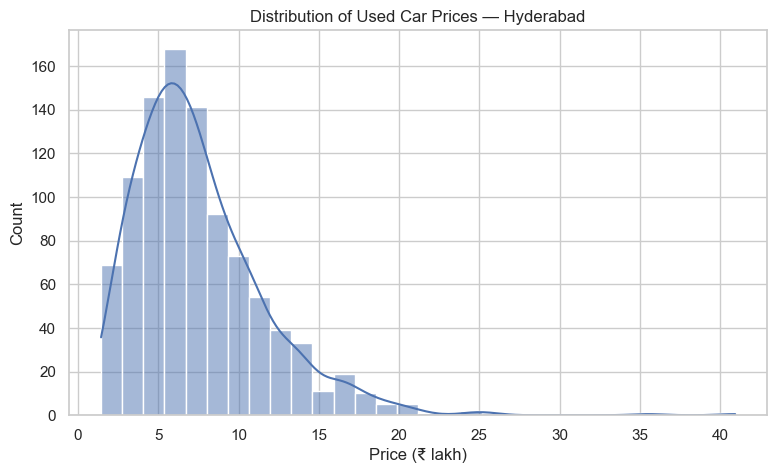

In [20]:
fig, ax = plt.subplots()
sns.histplot(df["price_lakh"].dropna(), bins=30, kde=True, ax=ax)
ax.set_xlabel("Price (₹ lakh)")
ax.set_title("Distribution of Used Car Prices — Hyderabad")
plt.show()


### 5.2 Cars by model year

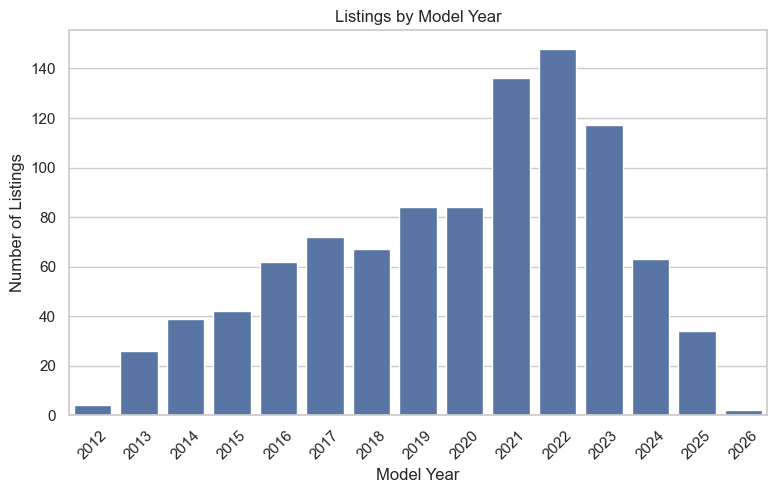

In [21]:
fig, ax = plt.subplots()
year_counts = df["year"].value_counts().sort_index()
sns.barplot(x=year_counts.index.astype(int), y=year_counts.values, ax=ax, color="#4C72B0")
ax.set_xlabel("Model Year")
ax.set_ylabel("Number of Listings")
ax.set_title("Listings by Model Year")
plt.xticks(rotation=45)
plt.show()


### 5.3 Top 15 brands by listing count

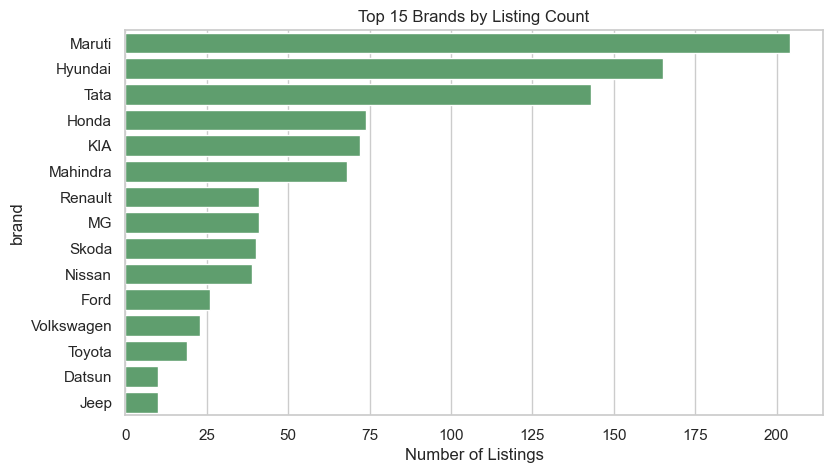

In [22]:
fig, ax = plt.subplots()
top_brands = df["brand"].value_counts().head(15)
sns.barplot(x=top_brands.values, y=top_brands.index, ax=ax, color="#55A868")
ax.set_xlabel("Number of Listings")
ax.set_title("Top 15 Brands by Listing Count")
plt.show()


### 5.4 Fuel type distribution

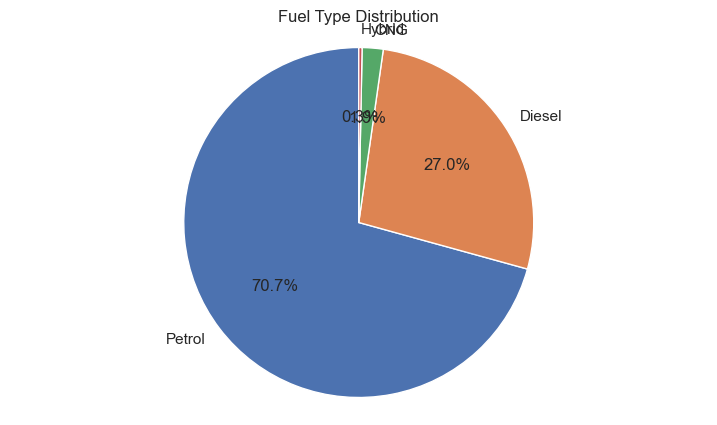

In [23]:
fig, ax = plt.subplots()
fuel_counts = df["fuel_type"].value_counts()
ax.pie(fuel_counts.values, labels=fuel_counts.index, autopct="%1.1f%%", startangle=90)
ax.set_title("Fuel Type Distribution")
ax.axis("equal")
plt.show()


### 5.5 Transmission and stock type distribution

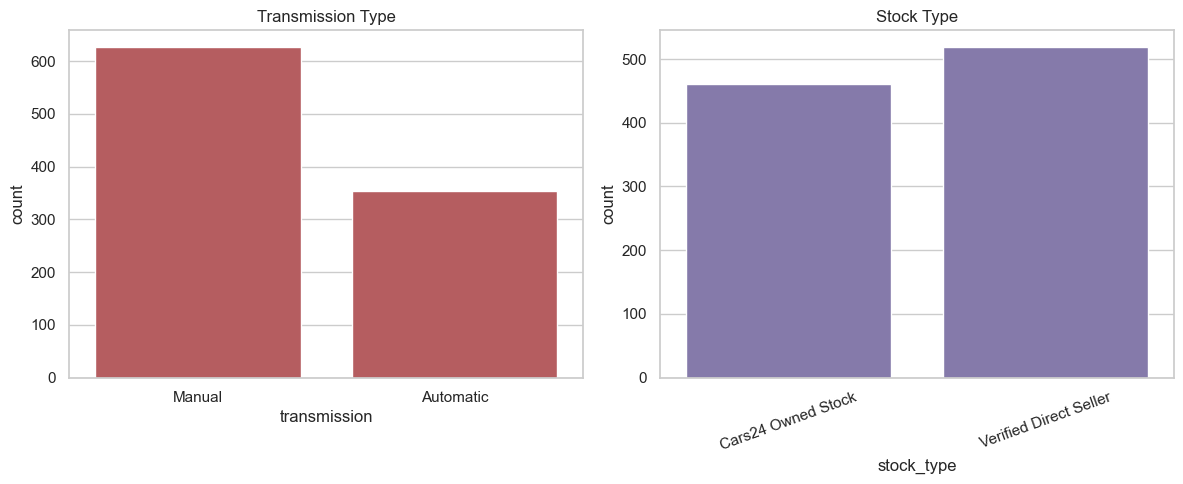

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.countplot(x="transmission", data=df, ax=axes[0], color="#C44E52")
axes[0].set_title("Transmission Type")
sns.countplot(x="stock_type", data=df, ax=axes[1], color="#8172B2")
axes[1].set_title("Stock Type")
axes[1].tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.show()


### 5.6 Price by fuel type and transmission

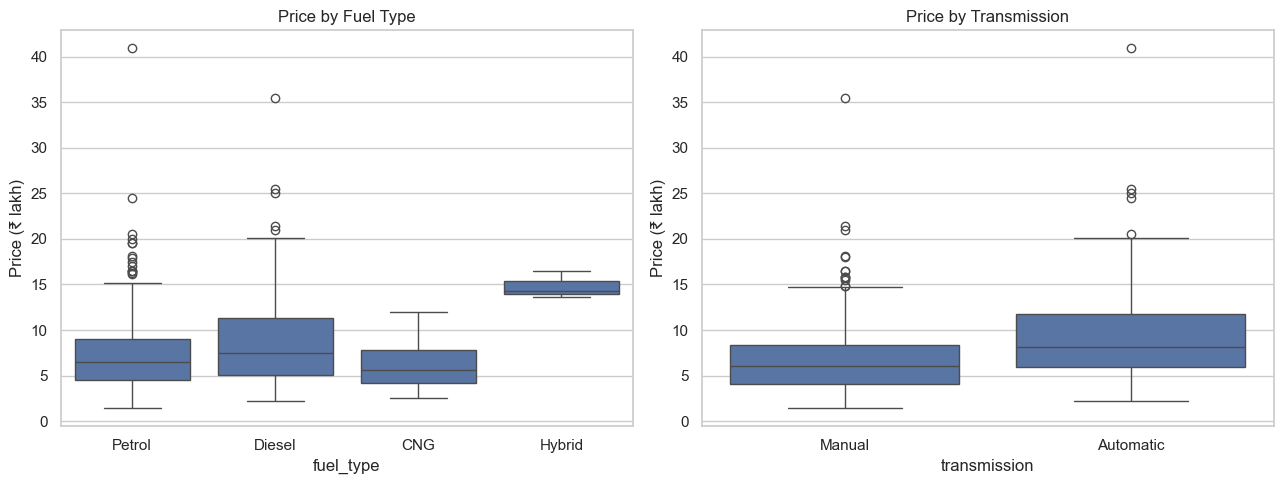

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.boxplot(x="fuel_type", y="price_lakh", data=df, ax=axes[0])
axes[0].set_title("Price by Fuel Type")
axes[0].set_ylabel("Price (₹ lakh)")

sns.boxplot(x="transmission", y="price_lakh", data=df, ax=axes[1])
axes[1].set_title("Price by Transmission")
axes[1].set_ylabel("Price (₹ lakh)")
plt.tight_layout()
plt.show()


### 5.7 Average price by model year

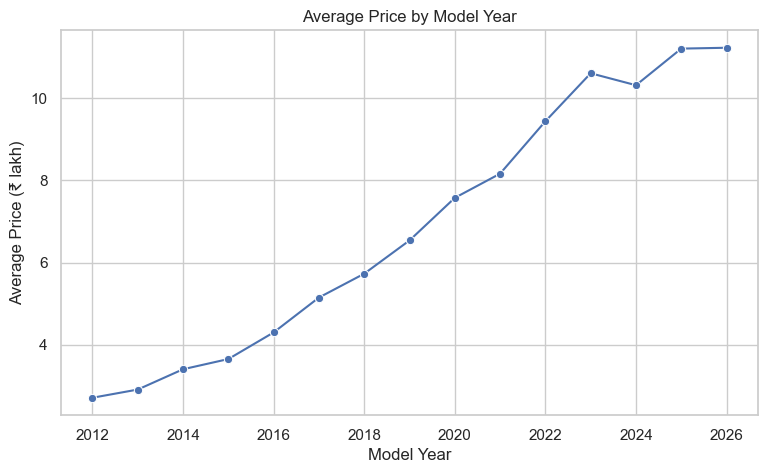

In [26]:
fig, ax = plt.subplots()
avg_price_by_year = df.groupby("year")["price_lakh"].mean().sort_index()
sns.lineplot(x=avg_price_by_year.index, y=avg_price_by_year.values, marker="o", ax=ax)
ax.set_xlabel("Model Year")
ax.set_ylabel("Average Price (₹ lakh)")
ax.set_title("Average Price by Model Year")
plt.show()


### 5.8 Correlation between year, price, and km driven

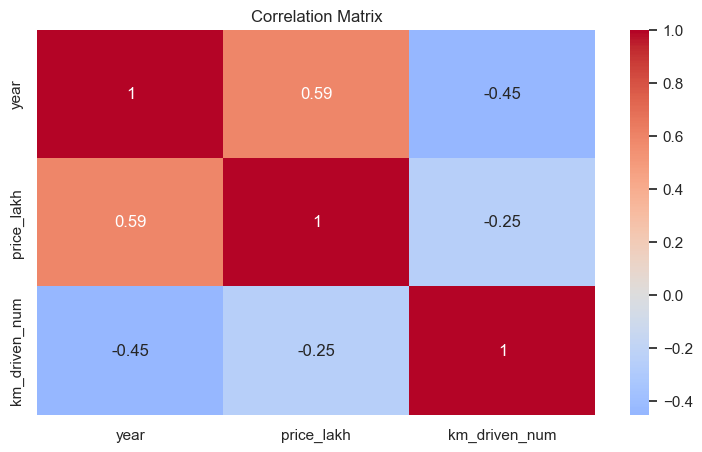

In [27]:
fig, ax = plt.subplots()
corr = df[["year", "price_lakh", "km_driven_num"]].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0, ax=ax)
ax.set_title("Correlation Matrix")
plt.show()


### 5.9 Price vs. kilometers driven

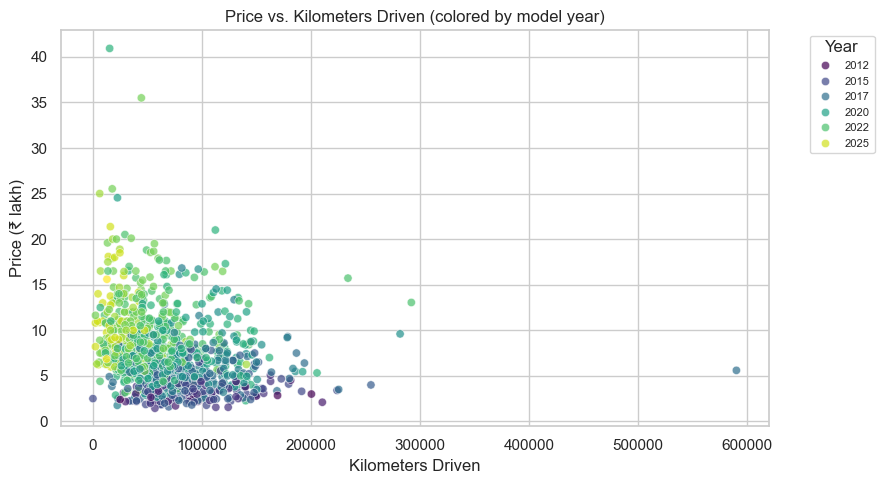

In [28]:
fig, ax = plt.subplots()
sns.scatterplot(
    x="km_driven_num", y="price_lakh", hue="year", data=df,
    palette="viridis", alpha=0.7, ax=ax
)
ax.set_xlabel("Kilometers Driven")
ax.set_ylabel("Price (₹ lakh)")
ax.set_title("Price vs. Kilometers Driven (colored by model year)")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", title="Year", ncol=1, fontsize=8)
plt.tight_layout()
plt.show()


### 5.10 Top locations by listing count

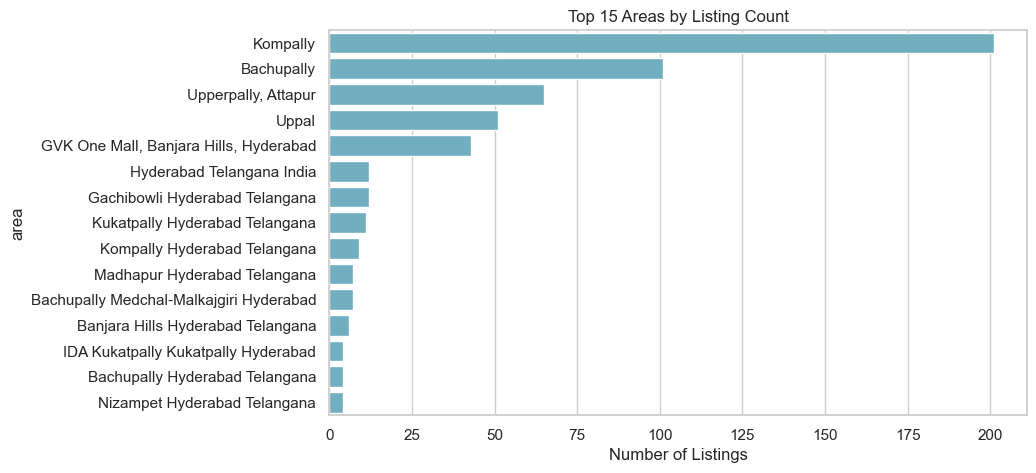

In [29]:
fig, ax = plt.subplots()
top_areas = df["area"].value_counts().head(15)
sns.barplot(x=top_areas.values, y=top_areas.index, ax=ax, color="#64B5CD")
ax.set_xlabel("Number of Listings")
ax.set_title("Top 15 Areas by Listing Count")
plt.show()


## 6. Business Insights & Recommendations
Findings below are computed directly from the cleaned dataset rather than asserted — each one references the underlying numbers.

In [30]:
top_brand = df["brand"].value_counts().idxmax()
top_brand_count = df["brand"].value_counts().max()

top_fuel = df["fuel_type"].value_counts().idxmax()
top_fuel_pct = (df["fuel_type"].value_counts(normalize=True).max() * 100)

top_transmission = df["transmission"].value_counts().idxmax()
top_transmission_pct = (df["transmission"].value_counts(normalize=True).max() * 100)

price_by_fuel = df.groupby("fuel_type")["price_lakh"].mean().sort_values(ascending=False)
price_by_transmission = df.groupby("transmission")["price_lakh"].mean().sort_values(ascending=False)

newest_year = int(df["year"].max())
oldest_year = int(df["year"].min())
price_newest = df[df["year"] == newest_year]["price_lakh"].mean()
price_oldest = df[df["year"] == oldest_year]["price_lakh"].mean()

top_area = df["area"].value_counts().idxmax()
top_area_count = df["area"].value_counts().max()

corr_price_km = df["price_lakh"].corr(df["km_driven_num"])
corr_price_year = df["price_lakh"].corr(df["year"])

print(f"Most-listed brand: {top_brand} ({top_brand_count} listings, "
      f"{top_brand_count / len(df) * 100:.1f}% of inventory)")
print(f"Dominant fuel type: {top_fuel} ({top_fuel_pct:.1f}% of listings)")
print(f"Dominant transmission: {top_transmission} ({top_transmission_pct:.1f}% of listings)")
print()
print("Average price by fuel type (₹ lakh):")
print(price_by_fuel.round(2))
print()
print("Average price by transmission (₹ lakh):")
print(price_by_transmission.round(2))
print()
print(f"Avg price, {newest_year} models: ₹{price_newest:.2f} lakh")
print(f"Avg price, {oldest_year} models: ₹{price_oldest:.2f} lakh")
print()
print(f"Top locality by inventory: {top_area} ({top_area_count} listings)")
print()
print(f"Correlation — price vs. km driven: {corr_price_km:.2f}")
print(f"Correlation — price vs. model year: {corr_price_year:.2f}")


Most-listed brand: Maruti (204 listings, 20.8% of inventory)
Dominant fuel type: Petrol (70.7% of listings)
Dominant transmission: Manual (64.0% of listings)

Average price by fuel type (₹ lakh):
fuel_type
Hybrid    14.81
Diesel     8.74
Petrol     7.07
CNG        6.20
Name: price_lakh, dtype: float64

Average price by transmission (₹ lakh):
transmission
Automatic    9.28
Manual       6.55
Name: price_lakh, dtype: float64

Avg price, 2026 models: ₹11.22 lakh
Avg price, 2012 models: ₹2.71 lakh

Top locality by inventory: Kompally (201 listings)

Correlation — price vs. km driven: -0.25
Correlation — price vs. model year: 0.59


### Key Findings

- **Brand concentration:** the market is led by whichever brand shows the highest count above — a useful signal for which models to prioritize when sourcing inventory or building comparison tools.
- **Fuel type:** the dominant fuel type's share (printed above) indicates what buyers are actually choosing in Hyderabad's used-car market right now — relevant for stocking or ad-targeting decisions.
- **Transmission premium/discount:** compare the average price by transmission above — automatics commanding a higher average price (a common pattern in Indian used-car markets) would support pricing automatics at a premium if this platform were setting prices.
- **Depreciation:** the price gap between the newest and oldest model years quantifies real depreciation in this sample — useful as a rough year-over-year value-loss estimate.
- **Price vs. km driven correlation:** a negative correlation here confirms the expected pattern (higher mileage → lower price) and its strength indicates how much mileage alone explains price versus other factors (brand, year, fuel type).
- **Geographic concentration:** the top locality's share of listings suggests where used-car supply (and likely demand) is currently concentrated in Hyderabad — relevant for a dealership deciding where to focus inventory or marketing spend.

### Recommendations

1. **Prioritize sourcing/stocking** the top 2–3 brands and fuel types identified above, since they represent the bulk of buyer interest reflected in listing volume.
2. **Price automatics and manuals separately** rather than applying a flat discount/premium, since the data shows a measurable average price gap between the two.
3. **Flag listings with unusually low price-per-km** (see Section 4.5) as potential high-value deals worth surfacing first to buyers, or worth double-checking for data quality if the price seems implausibly low.
4. **Concentrate marketing or inventory expansion** in the top-performing locality identified above, since it already carries a disproportionate share of supply and presumably matching demand.
5. **Use model year as a primary pricing lever** — given the correlation strength between year and price, a simple year-based pricing tier would capture most of the variance without needing a full valuation model.
